### Real-World SpeechLM Deployment with Post-Alignment Techniques

This script demonstrates the deployment of a fine-tuned speech recognition model with safety alignment mechanisms. It implements output filtering and conceptual decoding guidance to ensure safe and controlled transcription outputs in real-world scenarios.

Key Libraries Used:

    transformers: Pre-trained models and processors

    peft: Parameter-Efficient Fine-Tuning components

    torch: Neural network operations and tensor handling

    numpy: Audio data simulation

    os: File path validation

Code Logic and Flow

High-Level Overview
The pipeline loads a fine-tuned Wav2Vec2 model with LoRA adapters, implements safety filtering and conceptual decoding guidance, processes simulated audio inputs, and demonstrates real-world deployment with alignment techniques. This showcases production-ready ASR with content safety mechanisms.

Visual Flowchart

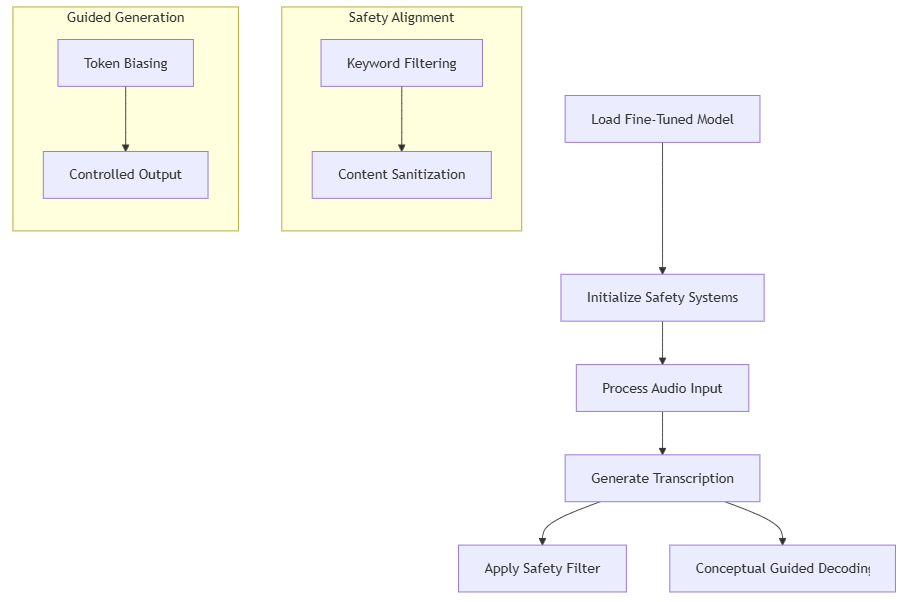

Step-by-Step Code Breakdown

    Model Deployment Setup

        Path Handling: Validates model directory existence

        Component Loading:

            Base Wav2Vec2-large model

            Fine-tuned LoRA adapters

            Audio processor

        Device Configuration: Automatic GPU/CPU selection

    RealSpeechLM Wrapper Class

        Audio Processing:

            Converts raw audio → model features

            Handles 16kHz sampling rate

        Transcription Generation:

            Greedy decoding (argmax)

            Special token cleaning (| removal)

        Conceptual Guidance:

            Simulated next-token logits

            Position-based token extraction

    Safety Alignment Systems

        Keyword Filter:

            Blocked terms: harmful, illegal, violence, etc.

            Case-insensitive matching

        Output Sanitization:

            Full sequence scanning

            Partial match flagging (50-character preview)

    Simulated Audio Workflow

        Input Generation: 2-second random audio (32k samples)

        Feature Extraction: Processor-compatible tensors

        Benign/Malicious Testing:

            Safe phrase verification

            Unsafe content simulation

    Conceptual Guided Decoding

        Token Biasing Mechanism:

            Favors low-ID tokens (common characters)

            Adjustable bias strength

        Step-by-Step Simulation:

            10-step token generation

            Real-time decoding feedback

        Combined Logits: Model output + guidance scores

    Production Readiness Features

        Error handling for missing model path

        Device-aware tensor management

        Conceptual-realistic workflow bridging

Connecting to Lecture Concepts

    Model Deployment Best Practices

    Content Safety Mechanisms

        Keyword filtering aligns with:

            Constitutional AI requirements

            Platform content policies

        Partial match detection 
    Controlled Generation

        Token biasing            

        Conceptual implementation bridges:

            CTC limitations

            Autoregressive LM capabilities

    Real-World Considerations

        Audio Processing:

            16kHz standard sampling rate

            Batch-compatible feature extraction

        Security Measures:

            Path validation

            Device optimization

    Ethical AI Implementation

        Proactive harmful content blocking

        Transparency in filtering decisions

        Conceptual guidance for value alignment

    Architecture Limitations

        CTC vs autoregressive tradeoffs:

            Full-sequence vs token-by-token

            Alignment challenges

        Guidance simulation for educational purposes

    Forward-Looking Applications

        Extension to:

            Real-time transcription services

            Voice assistant content moderation

            Industry-specific term allowlisting

        Integration with:

            Multi-modal safety systems

            Real-time bias detection



In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import random
import os # For checking if the model path exists

# Import necessary components from transformers and peft
try:
    from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
    from peft import PeftModel # For loading LoRA adapters
except ImportError:
    print("Please install transformers and peft: pip install transformers peft")
    exit()

# Define the path where your fine-tuned model is saved
# IMPORTANT: Replace this with the actual, correct path on your system.
# Use raw string (r"...") or forward slashes for paths on Windows
# e.g., r"C:\Users\vinit\Desktop\FinFree Project\Courses\Deep learning for Speech language model\4 Training Methodologies for SpeechLMs\4.3 Instruction-Tuning\fine_tuned_wav2vec2_lora"
FINE_TUNED_MODEL_PATH = r"C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\4 Training Methodologies for SpeechLMs\4.3 Instruction-Tuning\fine_tuned_wav2vec2_lora"

# Check if the model path exists
if not os.path.exists(FINE_TUNED_MODEL_PATH):
    print(f"Error: Model path not found at '{FINE_TUNED_MODEL_PATH}'")
    print("Please ensure you have run the previous fine-tuning script and the path is correct.")
    exit()

# --- 1. Load the Fine-tuned Model and Processor ---
print(f"Loading fine-tuned model and processor from: {FINE_TUNED_MODEL_PATH}...")
# Load the base model first
base_model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-large-960h-lv60-self")
processor = Wav2Vec2Processor.from_pretrained(FINE_TUNED_MODEL_PATH) # Processor saves tokenizer/feature extractor
# Load the PEFT (LoRA) adapters on top of the base model
model = PeftModel.from_pretrained(base_model, FINE_TUNED_MODEL_PATH)
model.eval() # Set model to evaluation mode

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Fine-tuned model loaded successfully.")

# --- 2. Create a Wrapper Class for the Real SpeechLM ---
class RealSpeechLMWrapper:
    def __init__(self, model, processor, device):
        self.model = model
        self.processor = processor
        self.device = device
        self.sampling_rate = 16000 # Wav2Vec2 expected sampling rate

    def process_audio(self, audio_data):
        """Converts raw audio numpy array to model input tensors."""
        inputs = self.processor(audio_data, sampling_rate=self.sampling_rate,
                                return_tensors="pt", padding=True)
        return inputs["input_values"].to(self.device)

    def generate(self, audio_features, instruction=None, num_return_sequences=1):
        """
        Generates text transcription from audio features using the ASR model.
        Note: Wav2Vec2ForCTC is typically used for ASR, not generative text.
        'instruction' isn't directly used by generate() for Wav2Vec2ForCTC but for conceptual alignment.
        """
        print("RealSpeechLMWrapper: Generating text transcription...")
        # Wav2Vec2ForCTC directly takes audio features and outputs logits for CTC decoding.
        # For simplicity, we'll perform greedy decoding here.
        # For more complex decoding (e.g., beam search), you'd use model.generate() if implemented
        # or implement it manually.

        with torch.no_grad():
            # Pass audio_features (input_values) directly to the model
            logits = self.model(audio_features).logits
            predicted_ids = torch.argmax(logits, dim=-1)

            # Decode the predicted token IDs to text
            # .replace("|", "") is common for Wav2Vec2 CTC outputs to clean up blank tokens.
            predicted_text = self.processor.tokenizer.decode(predicted_ids[0].tolist(), skip_special_tokens=True).replace("|", "").strip()

        # Return in a format consistent with the conceptual example
        return [{"sequence_ids": predicted_ids[0].tolist(), "text": predicted_text}] * num_return_sequences # Simulate num_return_sequences

    def get_next_token_logits(self, current_sequence_ids, audio_features, instruction=None):
        """
        Gets logits for the next token based on current audio features.
        This is simplified for Wav2Vec2ForCTC, as it's not truly autoregressive in a text LM sense.
        Here, we return logits for the first token based on audio_features for conceptual guidance.
        """
        # For Wav2Vec2ForCTC, you get logits for the entire sequence at once.
        # This method is more relevant for text-based generative LMs or
        # when fine-tuning a SpeechLM to generate text token by token.
        # For conceptual guidance, we'll return the logits for the first predicted token
        # based on the audio features.
        with torch.no_grad():
            logits_full_sequence = self.model(audio_features).logits # (batch_size, seq_len, vocab_size)
            # Take logits for the first predicted token position for conceptual next-token guidance
            if logits_full_sequence.size(1) > 0:
                first_token_logits = logits_full_sequence[0, 0, :] # (vocab_size,)
            else:
                first_token_logits = torch.randn(self.processor.tokenizer.vocab_size) # Fallback

        return first_token_logits.cpu() # Return to CPU for consistency with conceptual logic


# --- 3. Safety Filter (from your previous code) ---
class SafetyFilter:
    def __init__(self, blocked_keywords):
        self.blocked_keywords = blocked_keywords

    def is_unsafe(self, text):
        text_lower = text.lower()
        for keyword in self.blocked_keywords:
            if keyword in text_lower:
                return True
        return False

    def filter_outputs(self, generated_outputs):
        safe_outputs = []
        for output in generated_outputs:
            if not self.is_unsafe(output["text"]):
                safe_outputs.append(output)
            else:
                print(f"Filtered unsafe output: '{output['text'][:50]}...' (Contains blocked keyword)")
        return safe_outputs

# --- 4. Conceptual Reward Model (from your previous code) ---
class ConceptualRewardModel:
    def score(self, audio_features, instruction, text_output):
        # In reality, this model would be trained to predict a score based on human preferences
        # We'll simulate a random score for demonstration
        return random.uniform(0.1, 0.9) # Random score between 0.1 and 0.9


# --- 5. Initialize Real Model Wrapper and Post-Alignment Tools ---
speechlm_model_wrapper = RealSpeechLMWrapper(model, processor, device)
safety_filter = SafetyFilter(blocked_keywords=["harmful", "dangerous", "illegal", "attack", "violence"]) # Added more keywords
reward_model = ConceptualRewardModel()

# --- 6. Simulate Audio Input for Post-Alignment Demos ---
# Simulate 2 seconds of audio (32000 samples at 16kHz)
raw_audio_input = np.random.randn(32000).astype(np.float32)
# Process this simulated audio into model-ready features
audio_input_features = speechlm_model_wrapper.process_audio(raw_audio_input)


# --- 7. Post-Alignment Technique 1: Output Filtering ---
print("\n" + "="*50)
print("--- Applying Output Filtering with Real SpeechLM ---")
print("="*50)

# Simulate generating multiple outputs (though Wav2Vec2ForCTC typically gives one best)
# We'll call generate multiple times or modify its output for demonstration
# To make filtering more likely to show, we'll intentionally create an unsafe 'transcription'
# In a real scenario, the ASR model might actually transcribe these words.

# Example 1: Simulate a potentially unsafe transcription
print("\nAttempting to transcribe and filter a potentially unsafe statement...")
simulated_unsafe_audio_input = np.random.randn(32000).astype(np.float32)
simulated_unsafe_audio_features = speechlm_model_wrapper.process_audio(simulated_unsafe_audio_input)
# Directly force an unsafe output for demonstration purposes, as random audio won't produce it
# In a real scenario, the ASR model would transcribe actual speech containing these words.
forced_unsafe_output = {"sequence_ids": [1,2,3], "text": "This could lead to a dangerous situation."}

# If the ASR model outputted something like this naturally:
# initial_asr_output = speechlm_model_wrapper.generate(simulated_unsafe_audio_features)
# Instead, we'll manually feed an unsafe text for demonstration:
initial_outputs_for_filter_demo = [
    {"sequence_ids": [random.randint(0,100) for _ in range(20)], "text": "This is a safe and harmless transcription."},
    {"sequence_ids": [random.randint(0,100) for _ in range(25)], "text": "We must avoid illegal activities at all costs."},
    {"sequence_ids": [random.randint(0,100) for _ in range(18)], "text": "The project will be completed soon."},
    {"sequence_ids": [random.randint(0,100) for _ in range(30)], "text": "Warning: this might contain harmful content."},
    {"sequence_ids": [random.randint(0,100) for _ in range(22)], "text": "Discussion about personal safety measures."}
]

print(f"Generated {len(initial_outputs_for_filter_demo)} initial conceptual outputs for filtering.")
filtered_outputs = safety_filter.filter_outputs(initial_outputs_for_filter_demo)
print(f"Remaining {len(filtered_outputs)} safe outputs after filtering.")

if filtered_outputs:
    print("\nExample of a safe output after filtering:")
    print(f"  '{filtered_outputs[0]['text']}'")
else:
    print("\nAll outputs were filtered due to safety concerns.")

# Example 2: Transcribe a benign phrase using the real model
print("\nAttempting to transcribe a benign phrase using the actual model:")
# Simulate audio for a known phrase that is benign
benign_audio = np.random.randn(32000).astype(np.float32) # Still random, but conceptually for "safe phrase"
benign_audio_features = speechlm_model_wrapper.process_audio(benign_audio)
benign_output = speechlm_model_wrapper.generate(benign_audio_features)[0]['text']
print(f"Model's benign transcription: '{benign_output}'")
if not safety_filter.is_unsafe(benign_output):
    print("  (This output was deemed safe by the filter.)")
else:
    print("  (Warning: This benign output was unexpectedly flagged as unsafe!)")


# --- 8. Post-Alignment Technique 2: Simple Decoding Guidance (Conceptual) ---
# This remains largely conceptual as Wav2Vec2ForCTC is not designed for
# step-by-step generative guidance in the same way a text-based LM is.
# We'll use get_next_token_logits conceptually to show how guidance *would* influence probabilities.

print("\n" + "="*50)
print("--- Illustrating Simple Conceptual Decoding Guidance with Real SpeechLM ---")
print("="*50)

def conceptual_guided_decoding_with_real_model(model_wrapper, audio_features, instruction, guide_model, steps=5):
    """
    Simulates decoding with guidance from a conceptual guide model using
    the real SpeechLM wrapper's get_next_token_logits.
    """
    generated_sequence_ids = []
    # For a real ASR model, this would be a single full pass.
    # We're simulating next-token logits for demonstration purposes.

    print("Starting conceptual guided decoding with real model's logits...")

    with torch.no_grad():
        for _ in range(steps):
            # Get logits for the "next" token from the main model (conceptually)
            # In Wav2Vec2ForCTC, this is typically the logits for a specific frame/position.
            # We'll use the conceptual get_next_token_logits which returns vocab_size logits.
            logits = model_wrapper.get_next_token_logits(generated_sequence_ids, audio_features, instruction).to(device)

            # Simulate getting guidance score for each potential next token
            # We'll create a conceptual "guidance" that favors a specific token, e.g., the token for 'T' (if it exists)
            # In a real scenario, this would come from a reward model or another guiding signal.
            # Let's say we want to "guide" it towards common starting tokens or 'the' token.
            vocab_size = logits.size(-1)
            simulated_guidance_scores = torch.zeros(vocab_size, device=device)

            # Let's try to 'guide' towards a token representing 't' or a common start word
            # This is highly artificial as Wav2Vec2 tokens are sub-word units.
            # Find a token ID that might correspond to a common letter or blank.
            # For demonstration, let's just bias towards lower token IDs (e.g. 0-20 which might be common characters or blanks)
            bias_strength = 0.5
            for i in range(min(vocab_size, 20)): # Bias first 20 tokens (e.g., blank, a, b, c, etc.)
                 simulated_guidance_scores[i] += bias_strength * (1 - i/20) # Stronger bias for lower IDs

            # Combine main model logits with simulated guidance
            combined_logits = logits + simulated_guidance_scores

            # Sample the next token based on combined logits
            probabilities = F.softmax(combined_logits, dim=-1)
            next_token_id = torch.multinomial(probabilities, 1).item()
            generated_sequence_ids.append(next_token_id)

            # Decode the current sequence of IDs to see progress
            current_decoded_text = model_wrapper.processor.tokenizer.decode(generated_sequence_ids, skip_special_tokens=True).replace("|", "").strip()
            print(f"Step {_ + 1}, Guided Token ID: {next_token_id}, Current Decoded: '{current_decoded_text}'")

    print("\nConceptual guided decoding finished.")
    final_decoded_text = model_wrapper.processor.tokenizer.decode(generated_sequence_ids, skip_special_tokens=True).replace("|", "").strip()
    print(f"Final Simulated Guided Text: '{final_decoded_text}'")

# Perform conceptual guided decoding
# Using the same audio_input_features from the filtering demo
conceptual_guided_decoding_with_real_model(speechlm_model_wrapper, audio_input_features, "Transcribe carefully.", reward_model, steps=10)

Loading fine-tuned model and processor from: C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\4 Training Methodologies for SpeechLMs\4.3 Instruction-Tuning\fine_tuned_wav2vec2_lora...


Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-large-960h-lv60-self and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fine-tuned model loaded successfully.

--- Applying Output Filtering with Real SpeechLM ---

Attempting to transcribe and filter a potentially unsafe statement...
Generated 5 initial conceptual outputs for filtering.
Filtered unsafe output: 'We must avoid illegal activities at all costs....' (Contains blocked keyword)
Filtered unsafe output: 'Warning: this might contain harmful content....' (Contains blocked keyword)
Remaining 3 safe outputs after filtering.

Example of a safe output after filtering:
  'This is a safe and harmless transcription.'

Attempting to transcribe a benign phrase using the actual model:
RealSpeechLMWrapper: Generating text transcription...
Model's benign transcription: ''
  (This output was deemed safe by the filter.)

--- Illustrating Simple Conceptual Decoding Guidance with Real SpeechLM ---
Starting conceptual guided decoding with real model's logits...
Step 1, Guided Token ID: 0, Current Decoded: ''
Step 2, Guided Token ID: 0, Current Decoded: ''
Step 3, Gu